# Logistic Regression Pipeline — Machine Failure Prediction (scikit-learn only)

**Problem:** predict machine failure (`y` = 1) from `temp` (coolant temperature, °C) and `pressure` (psi).

Ground truth rule used to build the fake data (you don't get told this in real life — that's the point of the plots below): failure happens if temp is too low OR too high (U-shaped risk), OR if pressure is too high (roughly a straight cut). This notebook is the walkthrough of the *pipeline* — the sequence of questions I ask the data before I let a model near it — not a from-scratch implementation. You build the from-scratch version yourself; this one is scikit-learn only, as asked.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(0)  # only used for jitter in plots, not for the model

## Step 0 — load the data and just *look at the table*

Before any plot or any model: read the raw rows. You're not looking for patterns yet, just sanity-checking that nothing is obviously broken (wrong dtype, an impossible value, a label that isn't 0/1).

In [12]:
temp = np.array([30, 40, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 45, 95, 72, 88])
pressure = np.array([20, 25, 30, 35, 28, 32, 20, 22, 25, 30, 45, 50, 55, 60, 65, 70, 40, 48, 26, 52])
y = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1])

df = pd.DataFrame({'temp': temp, 'pressure': pressure, 'y': y})
df

,temp,pressure,y
0,30,20,1
1,40,25,1
2,50,30,1
3,55,35,0
4,60,28,0
5,65,32,0
6,70,20,0
7,75,22,0
8,80,25,0
9,85,30,0


## Step 1 — cheap numeric checks before any plot

Two questions, both from your own diagnostic checklist:
- **Are classes balanced?** (`y.mean()`) — if it were 0.05 or 0.95, accuracy would be a useless metric later and you'd need to know that *now*, not after training.
- **Are feature scales comparable?** (`np.ptp`, peak-to-peak range) — tells you up front whether scaling will matter once you fit.

In [13]:
print("fraction of rows that are failures:", y.mean())
print("temp range (ptp):", np.ptp(temp))
print("pressure range (ptp):", np.ptp(pressure))

fraction of rows that are failures: 0.55
temp range (ptp): 85
pressure range (ptp): 50


Classes are close to balanced (11 failures / 20 rows), so accuracy will actually mean something later. Ranges are in the same ballpark for now — that will change once we engineer a squared feature, which is exactly why scaling comes *after* feature engineering, not before.

## Step 2 — plot EACH raw feature against the label, on its own

**Why this graph, first, always:** this is the fastest way to see whether a single feature separates the classes with a straight cut, or whether failures show up on *both* ends of the range (which a straight line can never handle).

Analogy: imagine sorting a deck of cards by one property at a time and looking for where red and black clump. If all the reds are on one side of a threshold, one straight cut fixes it. If reds show up at *both* ends and blacks sit in the middle, no straight cut will ever separate them — you need a curve, and you need to know that before you pick a model, not after it fails.

I jitter the y-values slightly (`y + small random noise`) purely so overlapping points at y=0 and y=1 don't stack invisibly on top of each other — the jitter carries no information, it's a visibility trick only.

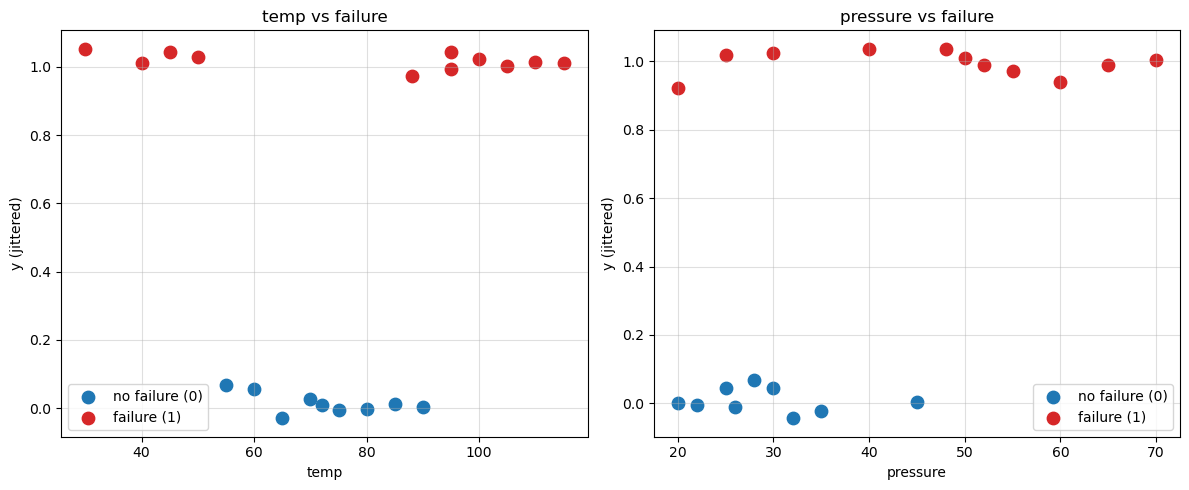

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, name in zip(axes, [temp, pressure], ['temp', 'pressure']):
    jitter = y + np.random.normal(0, 0.03, size=len(y))  # visual spread only, not real data
    ax.scatter(feature[y == 0], jitter[y == 0], c='tab:blue', label='no failure (0)', s=80)
    ax.scatter(feature[y == 1], jitter[y == 1], c='tab:red', label='failure (1)', s=80)
    ax.set_xlabel(name)
    ax.set_ylabel('y (jittered)')
    ax.set_title(f'{name} vs failure')
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

**Reading it:**
- `temp`: red points (failure) sit at BOTH the low end (~30-50) and the high end (~95-115), with blue points (safe) in a band in the middle (~55-90). Classic U-shape. A straight line threshold on temp alone cannot separate this — this is your "class 1 at both ends → squared term" signal from your own checklist.
- `pressure`: red points lean toward the high end, blue toward the low end, but there's real overlap around 40-50 (both colors present). A straight cut *roughly* works but isn't clean on its own — it needs the other feature to resolve the overlap.

## Step 3 — plot the two raw features against EACH OTHER, colored by label

**Why this graph:** logistic regression's raw decision boundary (before any feature engineering) is a straight line in this exact 2D space. Plotting it directly answers the question "can a straight line even separate these colors?" before you fit anything and get a misleadingly okay-looking accuracy number.

Analogy: this is the actual battlefield map. Step 2 showed you two 1D shadows of the battle; this shows you the real terrain where the line would have to be drawn.

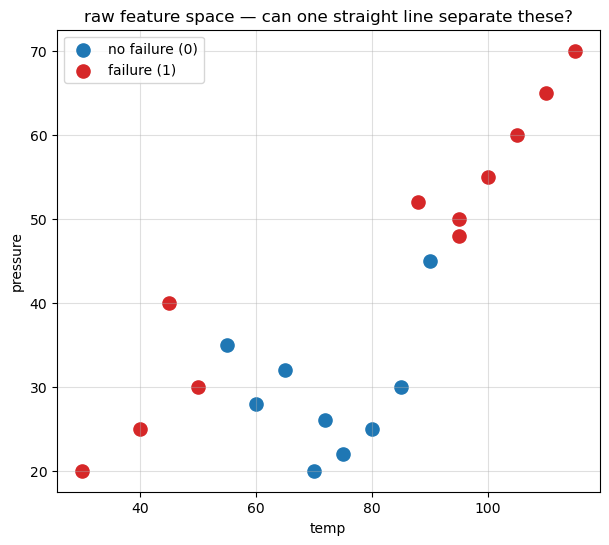

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(temp[y == 0], pressure[y == 0], c='tab:blue', label='no failure (0)', s=90)
plt.scatter(temp[y == 1], pressure[y == 1], c='tab:red', label='failure (1)', s=90)
plt.xlabel('temp')
plt.ylabel('pressure')
plt.title('raw feature space — can one straight line separate these?')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

No single straight line separates red from blue here: e.g. (temp=50, pressure=30, failure) sits in roughly the same neighborhood as (temp=85, pressure=30, safe). Confirms what Step 2 already hinted — we need an engineered feature before a linear model has a chance.

## Step 4 — feature engineering: turn the U-shape into something linear

**The idea:** logistic regression can only draw a straight line (or plane) in whatever feature space you hand it. temp's *risk* isn't linear in temp — it's linear in **distance from the safe zone**. So the feature to build isn't `temp`, it's `(temp - center)^2`.

Analogy: this is a Goldilocks zone. "Too cold" and "too hot" are both bad for the same underlying reason — distance from "just right" — not because high temp and low temp are independently bad in different ways. Squaring the deviation from the center converts "far in either direction" into one number that grows the same way regardless of which direction you drifted, which is exactly the kind of relationship a straight line CAN pick up on.

I pick the center as the mean temp among the rows that did NOT fail — that's my best empirical estimate of "the safe zone," read directly off the data rather than guessed.

In [17]:
safe_center = temp[y == 0].mean()
print("estimated center of the safe zone (mean temp among non-failures):", safe_center)

temp_dev_sq = (temp - safe_center) ** 2
df['temp_dev_sq'] = temp_dev_sq
df

estimated center of the safe zone (mean temp among non-failures): 72.44444444444444


,temp,pressure,y,temp_dev_sq
0,30,20,1,1801.530864
1,40,25,1,1052.641975
2,50,30,1,503.753086
3,55,35,0,304.308642
4,60,28,0,154.864198
5,65,32,0,55.419753
6,70,20,0,5.975309
7,75,22,0,6.530864
8,80,25,0,57.086420
9,85,30,0,157.641975


## Step 5 — sanity-check the engineered feature the SAME way you checked the raw ones

Never trust an engineered feature just because the math seems right — replot it against y exactly like Step 2, and confirm it actually turned the U-shape into a one-sided (linear-separable-looking) relationship. If it didn't, the feature is wrong, not the model.

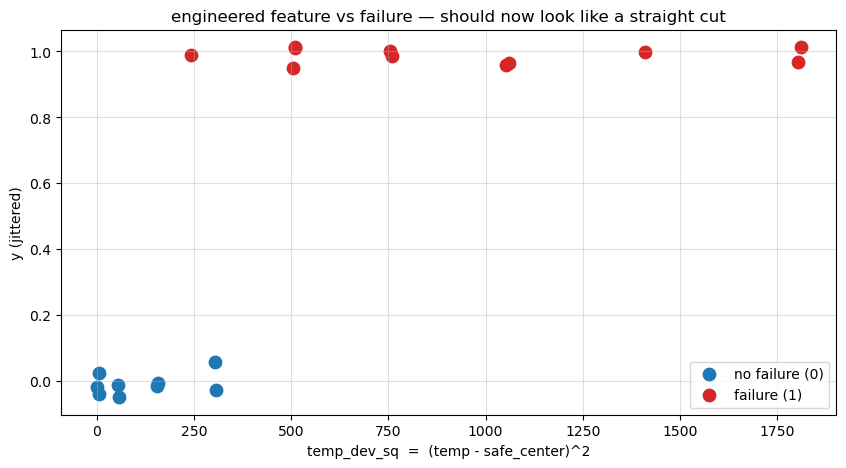

In [18]:
jitter = y + np.random.normal(0, 0.03, size=len(y))
plt.scatter(temp_dev_sq[y == 0], jitter[y == 0], c='tab:blue', label='no failure (0)', s=80)
plt.scatter(temp_dev_sq[y == 1], jitter[y == 1], c='tab:red', label='failure (1)', s=80)
plt.xlabel('temp_dev_sq  =  (temp - safe_center)^2')
plt.ylabel('y (jittered)')
plt.title('engineered feature vs failure — should now look like a straight cut')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

Now the reds are cleanly on the high side and blues on the low side — one threshold on this single number does almost all the work that two thresholds on raw `temp` couldn't. That's the engineered feature earning its place.

## Step 6 — check scale AFTER engineering, before fitting

This is why scaling comes after feature engineering, not before: squaring a deviation can easily blow the range of one feature up relative to the others. `LogisticRegression`'s default solver (`lbfgs`) is curvature/gradient-based, so a feature with a much larger numeric range can dominate the optimization purely because of its units, not because it's more predictive.

In [19]:
print("pressure range (ptp):", np.ptp(pressure))
print("temp_dev_sq range (ptp):", np.ptp(temp_dev_sq))

pressure range (ptp): 50
temp_dev_sq range (ptp): 1810.777777777778


`temp_dev_sq` ranges over a much wider span than `pressure` purely from squaring — confirms scaling is needed before this goes into the model.

## Step 7 — train/test split

Honest caveat, not glossed over: 20 rows is too small for a test split to mean much statistically — with 6 test points, one flipped prediction swings accuracy by ~17%. I'm doing the split anyway because the point of this notebook is the *pipeline shape*, and `stratify=y` keeps the class balance consistent across train/test so the split itself doesn't introduce a lopsided evaluation on top of the small-sample noise. In a real project you'd want orders of magnitude more rows before trusting a held-out score.

In [20]:
X = np.column_stack([pressure, temp_dev_sq])  # (m, 2) — sklearn requires 2-D X

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

X_train shape: (14, 2)  X_test shape: (6, 2)


## Step 8 — scale: fit on train only, transform train and test

`fit` learns mu/sigma from the training data only. `transform` applies those same numbers to test data. Fitting the scaler on test data (or on train+test combined) would leak information about the test set's distribution into training — the model would implicitly "see" the test set's scale before ever being evaluated on it.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only — never fit_transform here

print("scaler mean_:", scaler.mean_)
print("scaler scale_:", scaler.scale_)

scaler mean_: [ 38.64285714 540.4356261 ]
scaler scale_: [ 12.56757246 487.40285489]


## Step 9 — fit the model

Nothing fancy: create, fit, read the learned attributes. `lbfgs` is quasi-Newton (uses curvature), not plain gradient descent, so there's no learning rate to tune and it converges in very few iterations.

In [22]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("coef_ (w for [pressure, temp_dev_sq]):", model.coef_)
print("intercept_ (b):", model.intercept_)
print("n_iter_:", model.n_iter_)

coef_ (w for [pressure, temp_dev_sq]): [[0.92375735 1.41423299]]
intercept_ (b): [0.44997662]
n_iter_: [5]


## Step 10 — evaluate: accuracy AND confusion matrix, not accuracy alone

Even with balanced classes, accuracy collapses two different kinds of mistakes into one number. Here a **false negative** (predicting "safe" on a machine that actually fails) is the expensive error — a confusion matrix is what tells you whether your errors are the cheap kind or the costly kind. Accuracy alone would hide that distinction.

In [23]:
y_pred = model.predict(X_test_scaled)

print("accuracy:", accuracy_score(y_test, y_pred))
print("\nconfusion matrix (rows=true, cols=predicted, order=[0,1]):")
print(confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['no failure', 'failure']))

accuracy: 0.8333333333333334

confusion matrix (rows=true, cols=predicted, order=[0,1]):
[[3 0]
 [1 2]]

               precision    recall  f1-score   support

  no failure       0.75      1.00      0.86         3
     failure       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



## Step 11 — plot the decision boundary back in the ORIGINAL, human-readable space

**Why this graph:** the model's boundary is a straight line, but only in the scaled [pressure, temp_dev_sq] space — nobody thinks in "squared deviation from safe center" units. To make the boundary meaningful, map it back onto the original (temp, pressure) axes, where it will show up as a curved band, not a line.

**How:** build a grid over the original temp/pressure ranges, run every grid point through the *exact same* feature-engineering + scaling pipeline used on the training data, predict on the transformed grid, then plot the predicted regions back on the original axes.

Analogy: the model draws its fence on a warped map (the engineered/scaled space). To show someone the fence on the real map (temp vs pressure, the units they actually understand), you have to warp the grid the same way you warped the training data, trace the fence there, then project it back.

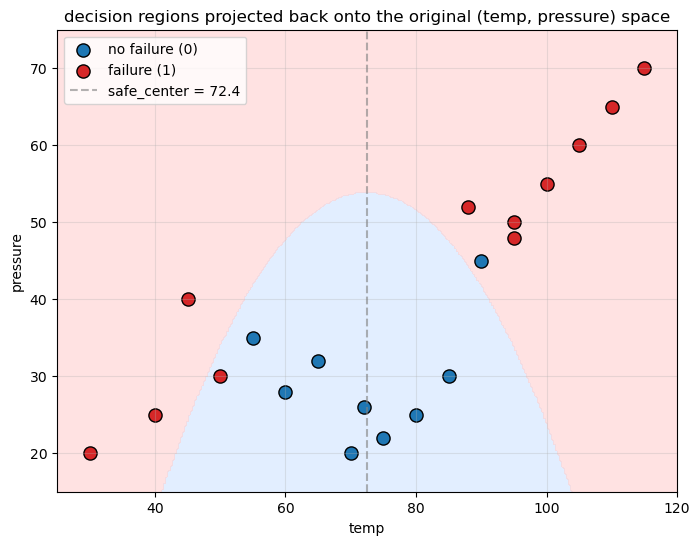

In [26]:
temp_grid = np.linspace(temp.min() - 5, temp.max() + 5, 300)
pressure_grid = np.linspace(pressure.min() - 5, pressure.max() + 5, 300)
TT, PP = np.meshgrid(temp_grid, pressure_grid)

# same feature engineering as training data, applied to every grid point
TT_dev_sq = (TT - safe_center) ** 2
grid_X = np.column_stack([PP.ravel(), TT_dev_sq.ravel()])
grid_X_scaled = scaler.transform(grid_X)  # same scaler, transform only

grid_pred = model.predict(grid_X_scaled).reshape(TT.shape)

plt.figure(figsize=(8, 6))
plt.contourf(TT, PP, grid_pred, levels=[-0.5, 0.5, 1.5], colors=['#cfe3ff', '#ffd0d0'], alpha=0.6)
plt.scatter(temp[y == 0], pressure[y == 0], c='tab:blue', label='no failure (0)', s=90, edgecolors='k')
plt.scatter(temp[y == 1], pressure[y == 1], c='tab:red', label='failure (1)', s=90, edgecolors='k')
plt.axvline(safe_center, color='gray', linestyle='--', alpha=0.6, label=f'safe_center = {safe_center:.1f}')
plt.xlabel('temp')
plt.ylabel('pressure')
plt.title('decision regions projected back onto the original (temp, pressure) space')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The predicted "safe" region (blue) is a vertical band centered on `safe_center`, narrowing as pressure rises — exactly the U-shaped-in-temp, threshold-in-pressure structure the model was built to capture. A model trained on raw `temp` and `pressure` with no engineering could only ever draw a straight line here; this curved band is the direct, visible payoff of Step 4.

## Step 12 — recap: the pipeline, mapped to your diagnostic checklist

1. Look at the raw table (Step 0) — catch broken data before it wastes your time.
2. `y.mean()` and `np.ptp()` on raw features (Step 1) — is this classification balanced, are scales already comparable?
3. Each feature vs label, individually (Step 2) — straight cut, or class 1 at both ends?
4. All features vs each other, colored by label (Step 3) — can a straight line separate this at all, in the space you currently have?
5. Engineer features to straighten out non-linear relationships you found (Step 4) — and justify *why* that transform, not just that it works.
6. Re-check the engineered feature the same way you checked the raw ones (Step 5) — don't trust the math, look at the plot.
7. Re-check scale AFTER engineering (Step 6) — squaring, in particular, changes ranges a lot.
8. Split, then scale — fit the scaler on train only (Steps 7-8).
9. Fit, read the learned coefficients (Step 9).
10. Evaluate with more than one metric — accuracy alone hides which kind of error you're making (Step 10).
11. Project the decision boundary back into a space a human can read, not just the transformed one (Step 11).

**Your turn:** rebuild this from scratch — no `LogisticRegression`, no `StandardScaler`. Same dataset, same engineered feature. Compare your scratch `coef_`/`intercept_` (after un-scaling, or just compare on the scaled features directly) against `model.coef_` / `model.intercept_` above as your check that the from-scratch version actually converged to the same place.